<a href="https://colab.research.google.com/github/dee431/McDonald-s-Menu-Prices-2026/blob/main/McDonald%E2%80%99s_Menu_Prices_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cell 1**

In [1]:
# Cell 1: Environment Setup & Dark Theme Configuration
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Pure Dark Theme Overrides for Matplotlib & Seaborn
plt.style.use("dark_background")
plt.rcParams["figure.facecolor"] = "#0e1117"
plt.rcParams["axes.facecolor"] = "#0e1117"
plt.rcParams["savefig.facecolor"] = "#0e1117"
plt.rcParams["text.color"] = "#ffffff"
plt.rcParams["axes.labelcolor"] = "#ffffff"
plt.rcParams["xtick.color"] = "#a0aec0"
plt.rcParams["ytick.color"] = "#a0aec0"
plt.rcParams["grid.color"] = "#1a202c"
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["figure.dpi"] = 150

print("Dark theme successfully initialized.")

Dark theme successfully initialized.


# **cell 2**

In [3]:
# Cell 2: Dataset Ingestion via Kaggle Paths
csv_path = "/content/mcdonalds_menu_20260827_202242-selected-columns.csv"

df = pd.read_csv(csv_path)

# Feature Engineering for Advanced Metrics
if "protein_per_dollar" not in df.columns and "protein_g" in df.columns:
    df["protein_per_dollar"] = df["protein_g"] / df["price_usd"]
if "price_per_calorie" not in df.columns and "calories" in df.columns:
    df["price_per_calorie"] = df["price_usd"] / df["calories"]

print(f"Dataset Loaded Successfully. Shape: {df.shape}")

Dataset Loaded Successfully. Shape: (80, 11)


# **Cell 3**

In [4]:
display(df.head(3))

,item_id,item_name,category,description,price_usd,calories,calories_from_fat,total_fat_g,saturated_fat_g,trans_fat_g,price_per_calorie
0,MCD_BURG_Big_Mac_325,Big Mac,Burgers,Signature big mac served hot and fresh,6.55,530,177,27,8.9,1.6,0.012358
1,MCD_BURG_Quarter_Pounder_with_Cheese_180,Quarter Pounder with Cheese,Burgers,Signature quarter pounder with cheese served h...,7.03,515,188,26,8.6,3.8,0.013650
2,MCD_BURG_Cheeseburger_723,Cheeseburger,Burgers,Delicious cheeseburger from McDonald's,6.81,291,113,13,6.1,1.8,0.023402


# **Cell 4**

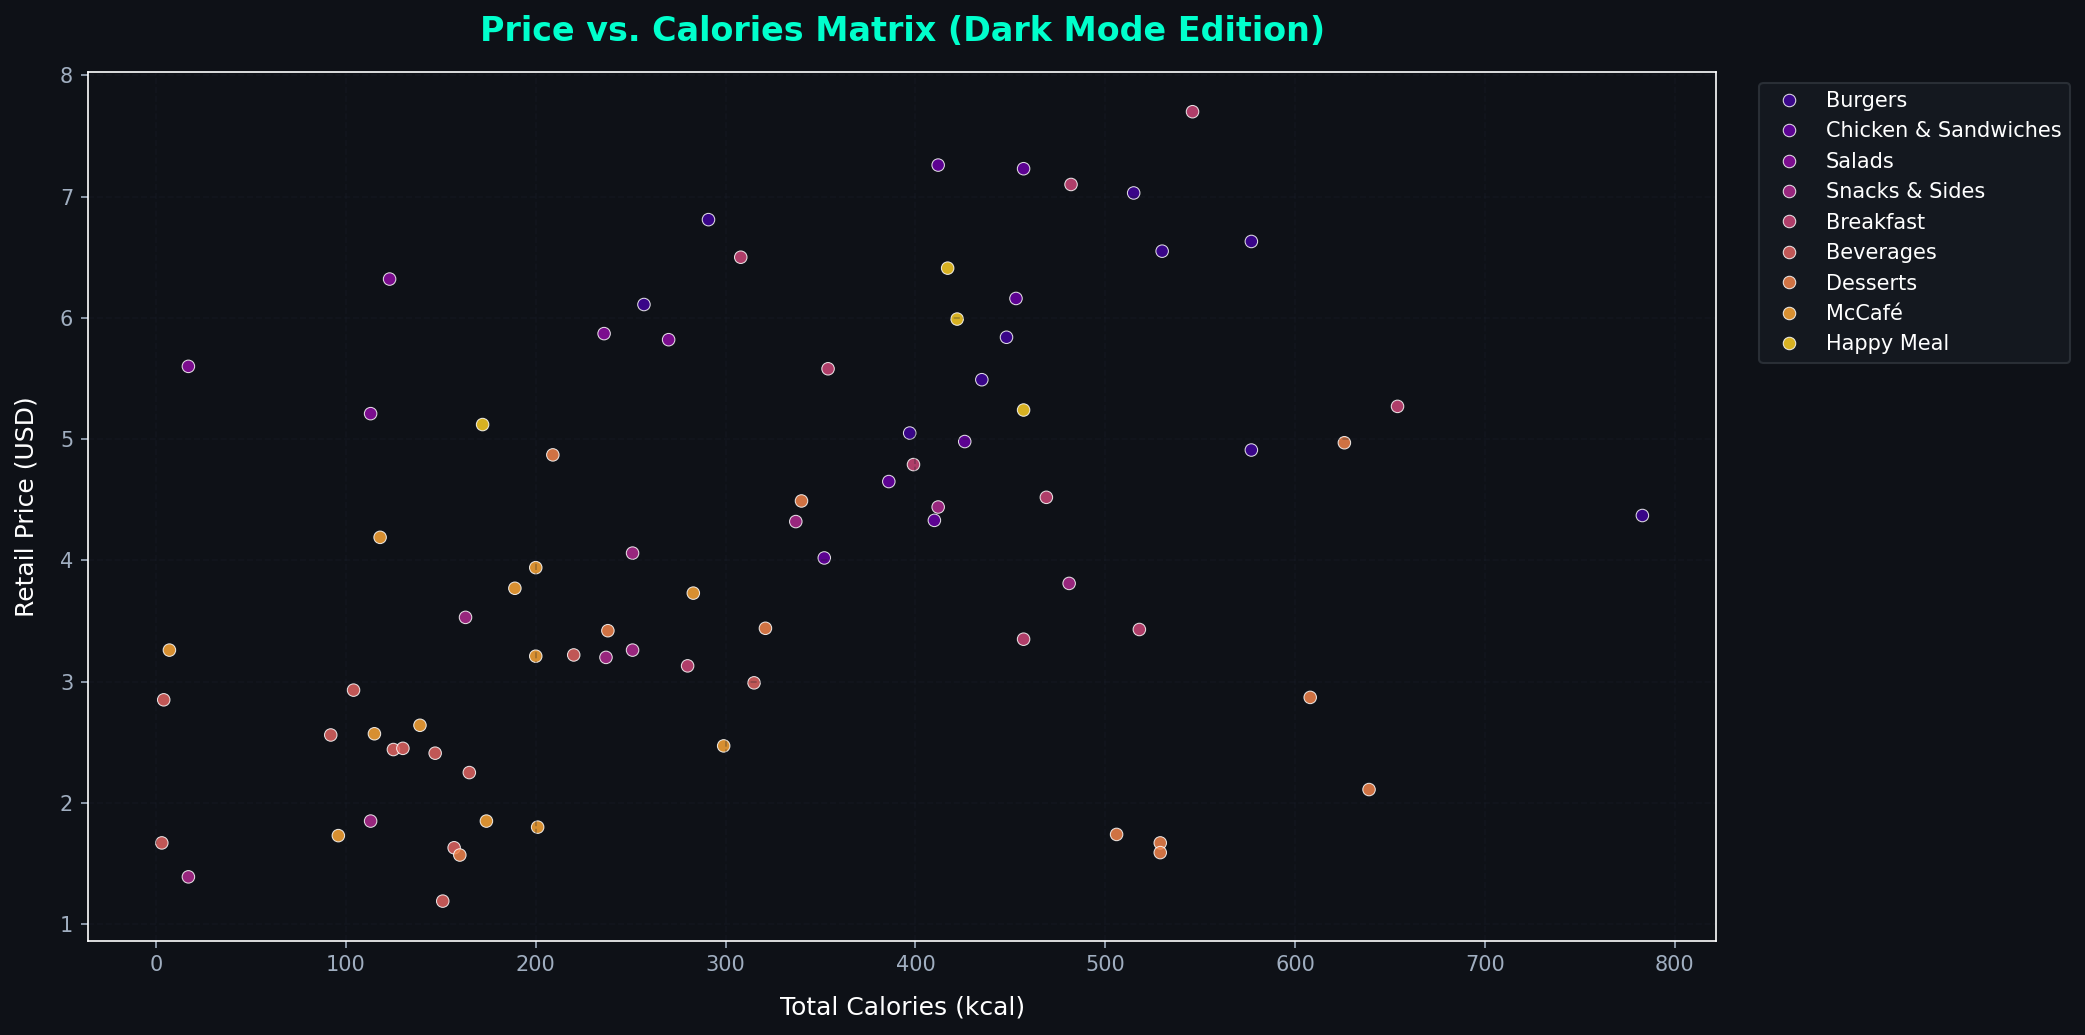

In [6]:
# Cell 3: Visualization 1 - Dark Plasma Scatter (Price vs Calories by Category)
# Dynamically determine the size variable based on available columns
size_col = None
for col in ["protein_g", "protein", "protein_per_dollar"]:
    if col in df.columns:
        size_col = col
        break

plt.figure(figsize=(14, 7))
ax = sns.scatterplot(
    data=df,
    x="calories",
    y="price_usd",
    hue="category",
    size=size_col,
    sizes=(30, 250) if size_col else None,
    palette="plasma",  # Using valid seaborn/matplotlib palette 'plasma'
    alpha=0.85,
    edgecolor="#ffffff",
    linewidth=0.5,
)

plt.title(
    "Price vs. Calories Matrix (Dark Mode Edition)",
    fontsize=16,
    fontweight="bold",
    pad=15,
    color="#00ffcc",
)
plt.xlabel("Total Calories (kcal)", fontsize=12, labelpad=10)
plt.ylabel("Retail Price (USD)", fontsize=12, labelpad=10)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    facecolor="#161b22",
    edgecolor="#30363d",
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Cell 5**

/tmp/ipykernel_1874/966860962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


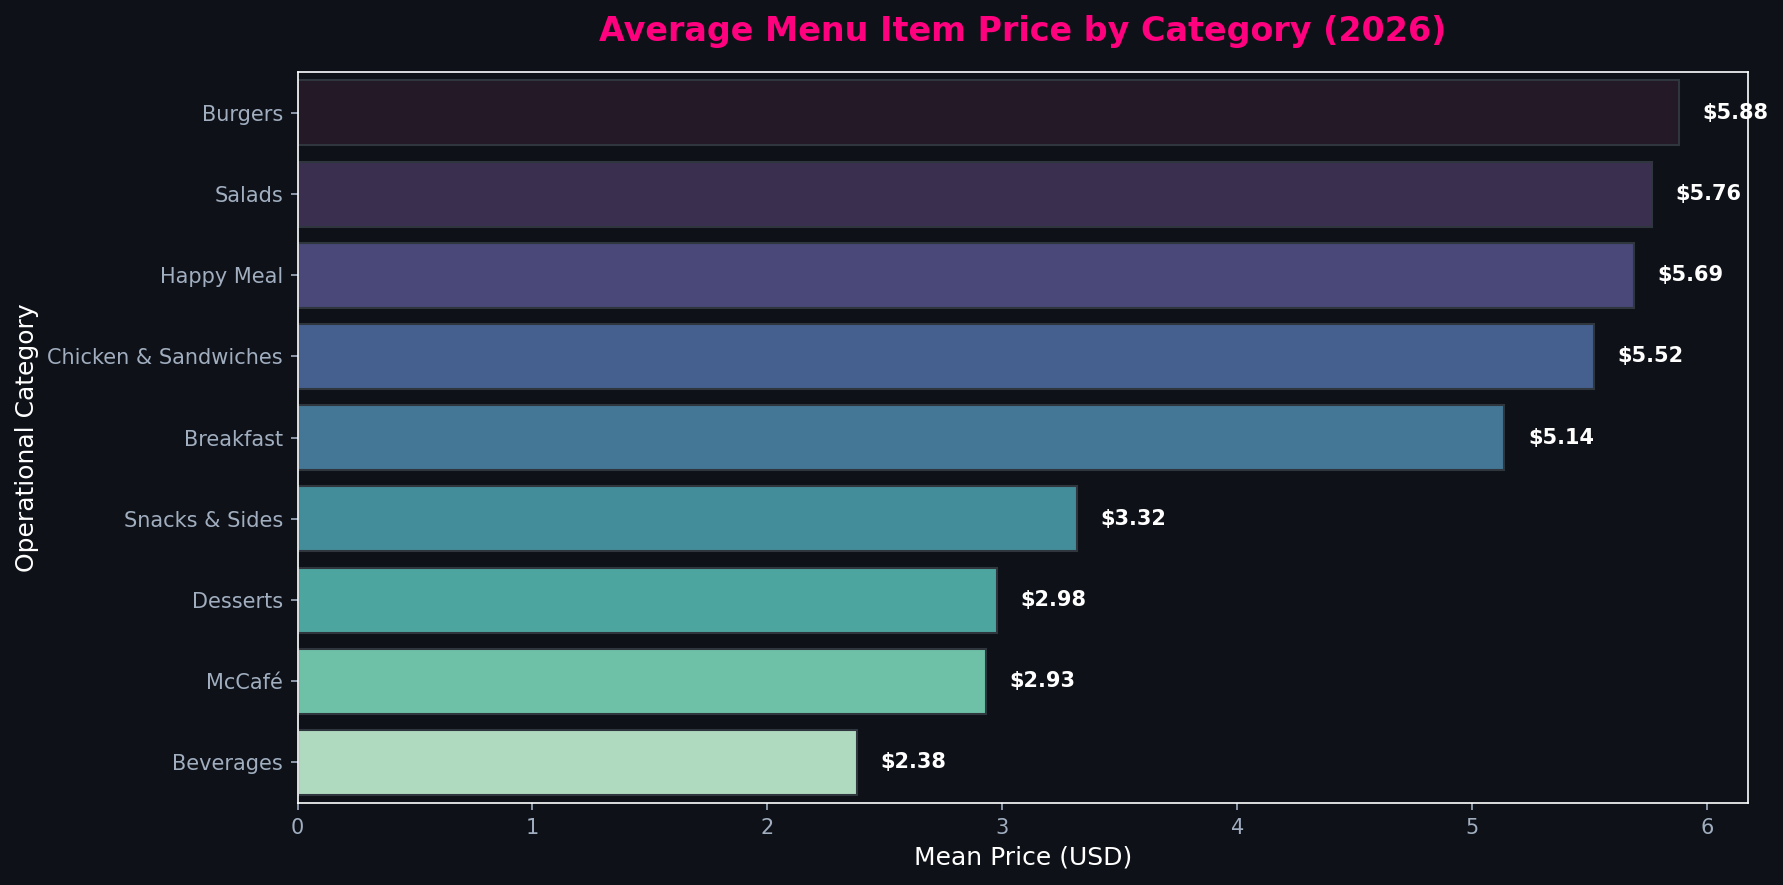

In [7]:
# Cell 4: Visualization 2 - Dark Gradient Bar Plot (Average Price by Category)
plt.figure(figsize=(12, 6))
avg_price_cat = (
    df.groupby("category")["price_usd"].mean().sort_values(ascending=False)
)

ax = sns.barplot(
    x=avg_price_cat.values,
    y=avg_price_cat.index,
    palette="mako",
    edgecolor="#30363d",
)

plt.title(
    "Average Menu Item Price by Category (2026)",
    fontsize=16,
    fontweight="bold",
    pad=15,
    color="#ff007f",
)
plt.xlabel("Mean Price (USD)", fontsize=12)
plt.ylabel("Operational Category", fontsize=12)

# Annotate values on bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"${width:.2f}",
        (width + 0.1, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        color="#ffffff",
        fontsize=10,
        fontweight="bold",
    )

ax.grid(False)
plt.tight_layout()
plt.show()

# **Cell 6**

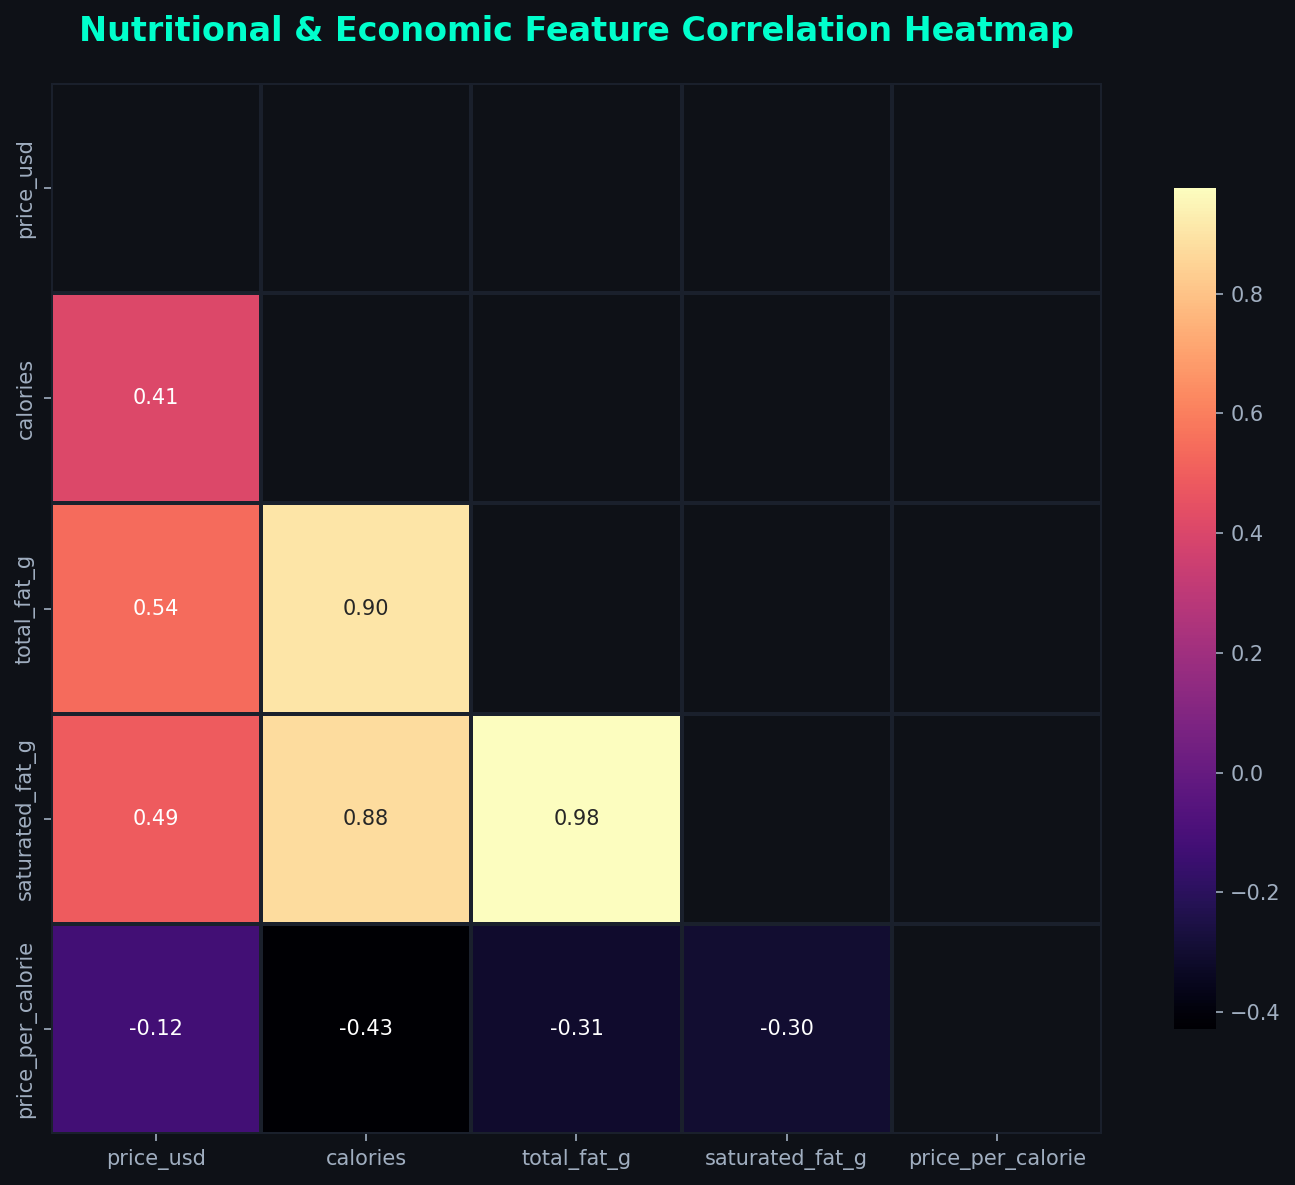

In [9]:
# Cell 5: Visualization 3 - Dark Heatmap (Correlation Matrix)
plt.figure(figsize=(10, 8))

# Dynamically select numeric columns that actually exist in the DataFrame
potential_numeric_cols = [
    "price_usd",
    "calories",
    "total_fat_g",
    "total_fat",
    "saturated_fat_g",
    "saturated_fat",
    "sodium_mg",
    "sodium",
    "total_carbs_g",
    "total_carbs",
    "protein_g",
    "protein",
    "protein_per_dollar",
    "price_per_calorie"
]

numeric_cols = [col for col in potential_numeric_cols if col in df.columns]

# Fallback to pandas automatic numeric detection if none of the above are matched
if not numeric_cols:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="magma",
    fmt=".2f",
    linewidths=1,
    linecolor="#1a202c",
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "Nutritional & Economic Feature Correlation Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#00ffcc",
)
plt.tight_layout()
plt.show()

# **Cell 7**

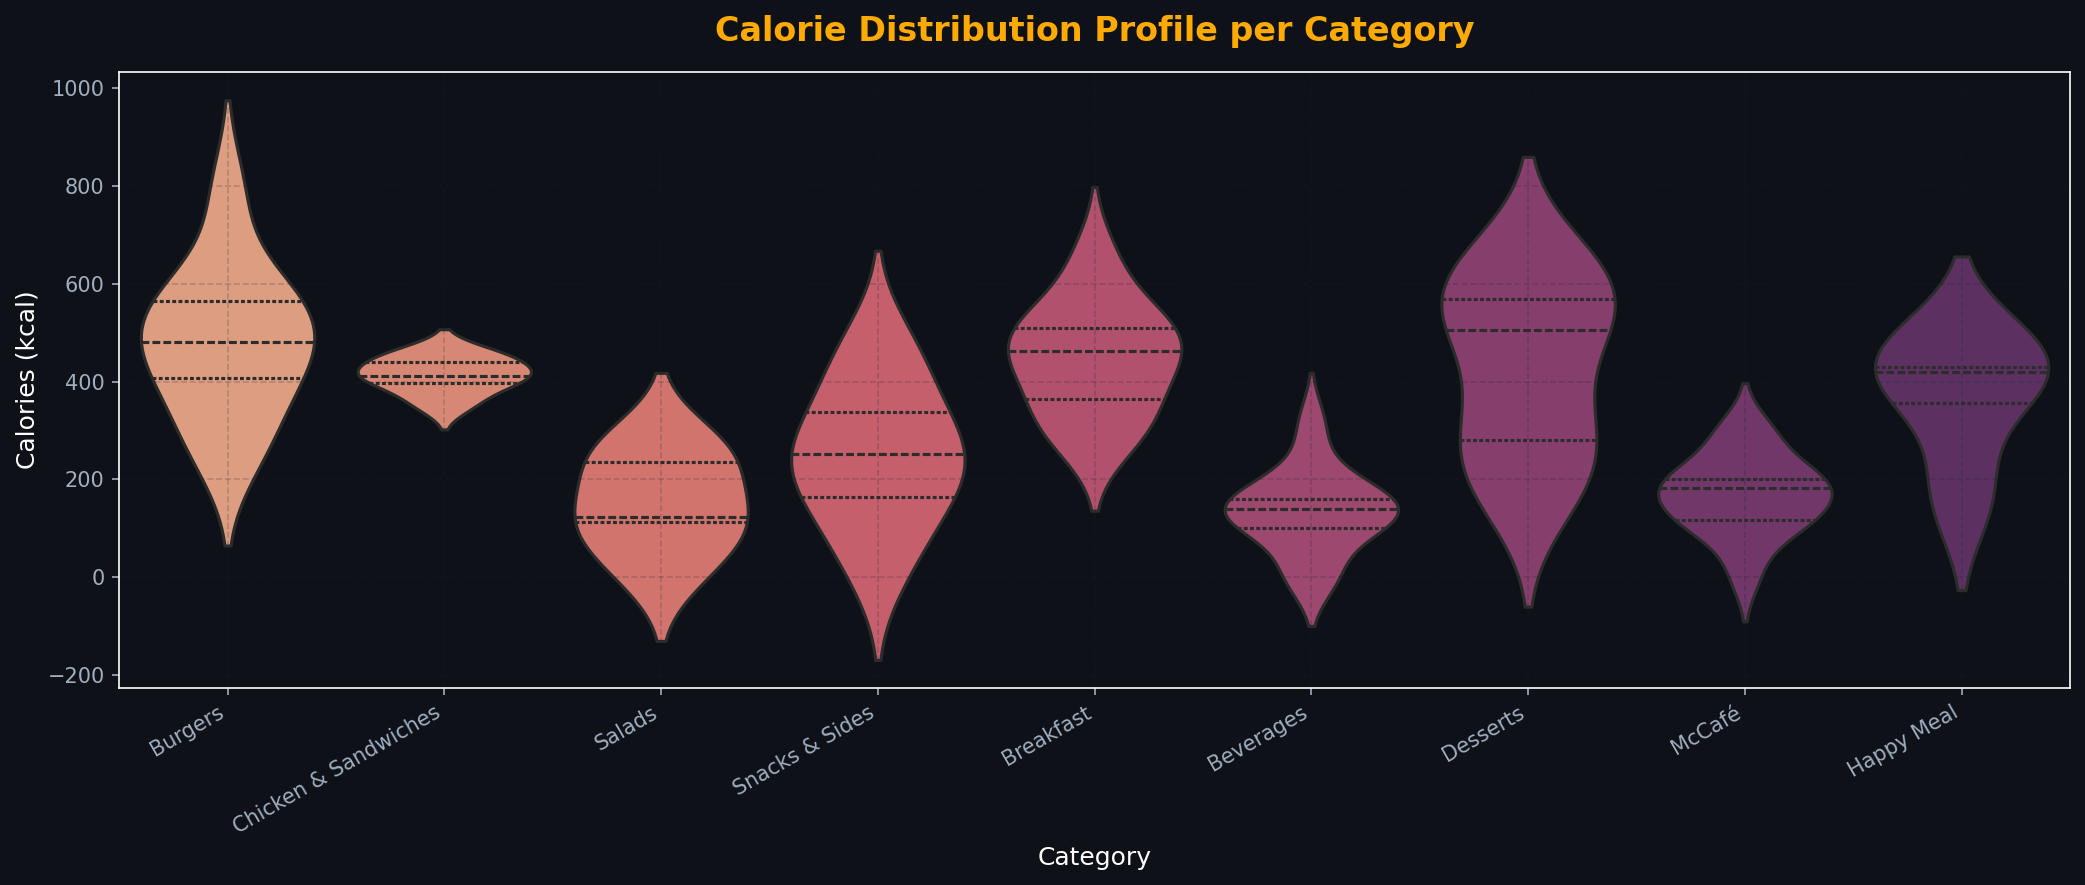

In [12]:
# Cell 6: Visualization 4 - Dark Violin Plot (Calories Distribution Across Categories)
plt.figure(figsize=(14, 6))
ax = sns.violinplot(
    data=df,
    x="category",
    y="calories",
    hue="category",
    legend=False,
    palette="flare",
    inner="quartile",
    linewidth=1.5,
)

plt.title(
    "Calorie Distribution Profile per Category",
    fontsize=16,
    fontweight="bold",
    pad=15,
    color="#ffaa00",
)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Calories (kcal)", fontsize=12)
plt.xticks(rotation=30, ha="right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# **Cell 8**

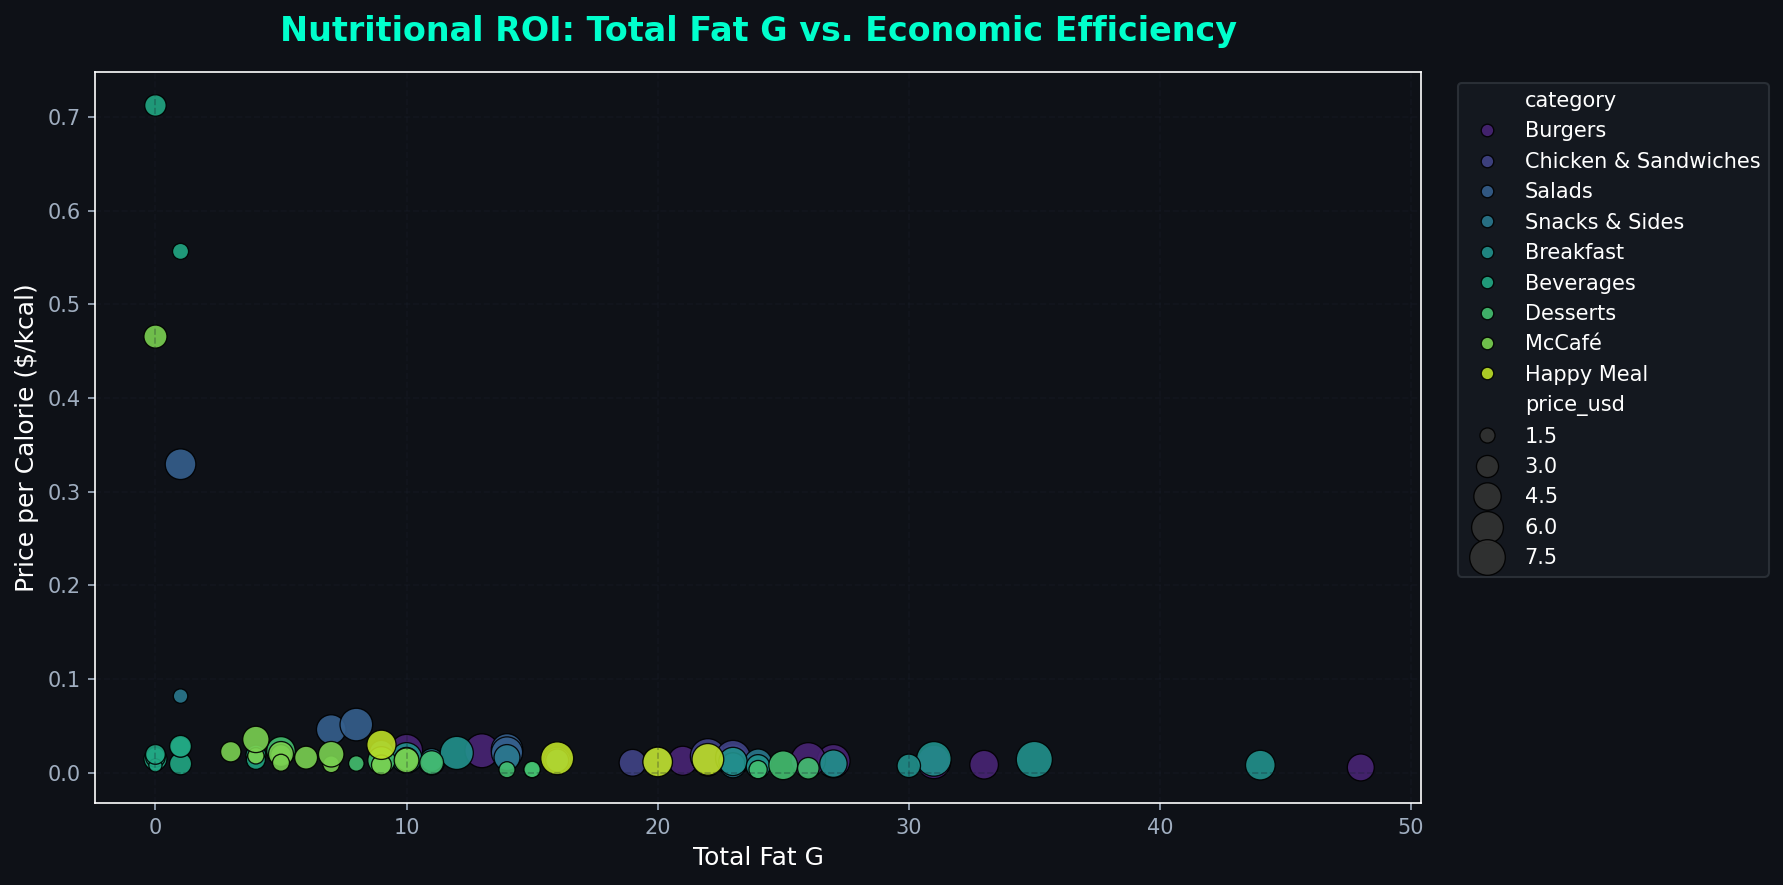

In [16]:
# Cell 7: Visualization 5 - Dark Economic Efficiency Bubble Chart
# Dynamically fallback to an available numeric nutrient column
x_metric = None
for col in ["protein_g", "protein", "total_fat_g", "total_fat", "calories"]:
    if col in df.columns:
        x_metric = col
        break

if x_metric:
    plt.figure(figsize=(12, 6))
    ax = sns.scatterplot(
        data=df,
        x=x_metric,
        y="price_per_calorie" if "price_per_calorie" in df.columns else "price_usd",
        hue="category",
        size="price_usd",
        sizes=(40, 300),
        palette="viridis",
        alpha=0.9,
        edgecolor="#000000",
    )

    y_label = "Price per Calorie ($/kcal)" if "price_per_calorie" in df.columns else "Retail Price (USD)"
    plt.title(
        f"Nutritional ROI: {x_metric.replace('_', ' ').title()} vs. Economic Efficiency",
        fontsize=16,
        fontweight="bold",
        pad=15,
        color="#00ffcc",
    )
    plt.xlabel(f"{x_metric.replace('_', ' ').title()}", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        facecolor="#161b22",
        edgecolor="#30363d",
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"No valid numeric column found. Available columns: {list(df.columns)}")